# HuggingFace Project

This project:
- Generates text from a user title
- Summarizes the text
- Generates an image related to the title
- Describes the generated image

In [3]:
import torch
import matplotlib.pyplot as plt
from PIL import Image

from transformers import pipeline

from diffusers import StableDiffusionPipeline

In [4]:
device = 0 if torch.cuda.is_available() else -1
print("Using GPU" if device == 0 else "Using CPU")

Using GPU


## Text Generation & Text Summarization

In [5]:
generator = pipeline("text-generation", model="gpt2", device=device)

summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    device=device
)

Device set to use cuda:0
Device set to use cuda:0


In [6]:
def generate(prompt):
    result = generator(prompt, max_new_tokens=100, truncation=True)
    text = result[0]["generated_text"]
    return text


def summarize(paragraph):
    result = summarizer(paragraph)
    summary = result[0]["summary_text"]
    return summary

In [7]:
title = input("Enter a title: ")

prompt = f"Write a short informative paragraph about {title}"

paragraph = generate(prompt)

summary = summarize(paragraph)

print("\nGenerated Paragraph:")
print(paragraph)

print("\nSummary:")
print(summary)

Enter a title:  Healthy life


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Your max_length is set to 142, but your input_length is only 110. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=55)



Generated Paragraph:
Write a short informative paragraph about Healthy life. I know what I'm talking about, in case it got too long.

The first part of the letter is about a new product called "Caffeine Resistant" and it's a light, easy to use ingredient.

What it does, is to help your brain to keep on working and improve every day.

So, for the rest of the letter, how do you make sure you're getting the best out of your caffeine?

Let's start with

Summary:
The first part of the letter is about a new product called "Caffeine Resistant" and it's a light, easy to use ingredient. Write a short informative paragraph about Healthy life. I know what I'm talking about, in case it got too long.


## Image Generation

In [8]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

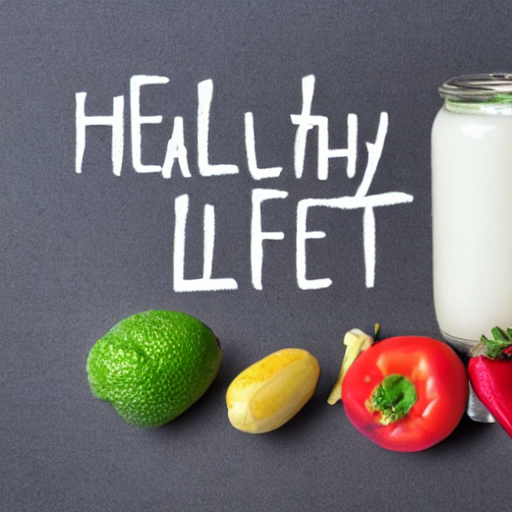

In [9]:
image = pipe(title).images[0]
image

## Image Description

In [10]:
image_describer = pipeline(
    "image-to-text",
    model="Salesforce/blip-image-captioning-base",
    device=0
)

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

C:\Users\Nourhan Yehia\.conda\envs\cnn_xray\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Nourhan Yehia\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


In [11]:
def describe_image(image):
    result = image_describer(image)
    description = result[0]["generated_text"]
    return description

In [12]:
description = describe_image(image)

print("\nImage Description:")
print(description)


Image Description:
a jar of milk, a glass of milk, and some fruit
